Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x uni

Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125


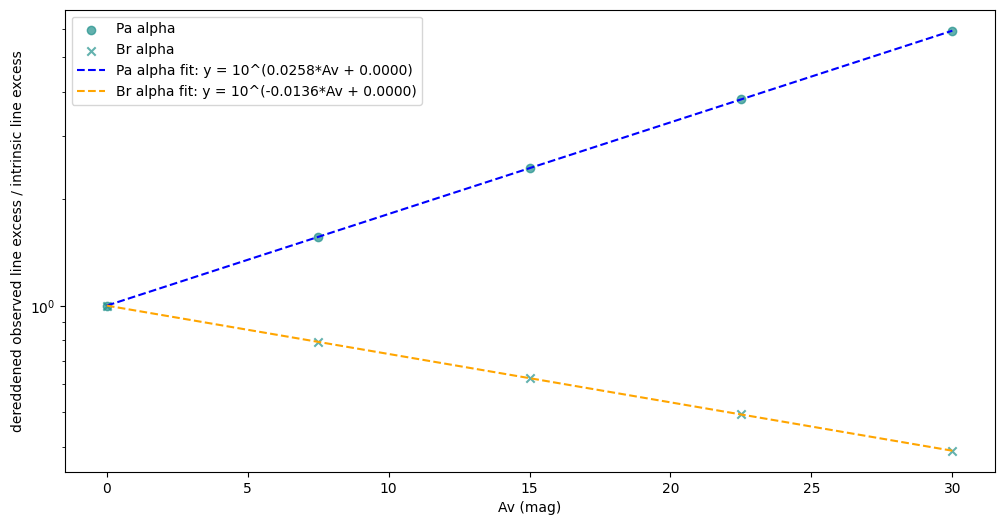

In [14]:
# make blackbody models with different tempearture and also models attenuated by dust extinction with various Av values
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from astropy.modeling import models
from astropy.modeling import fitting
from dust_extinction.averages import RL85_MWGC, G21_MWAvg
from dust_extinction.parameter_averages import CCM89
from astroquery.svo_fps import SvoFps
from scipy.optimize import curve_fit

def get_flux_ratio(wavelength, sed, narrow, wide):

   

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']


    # interpolate SED and wavelength to make the same cadence with waves_wide
    data_interpolated = np.interp(waves_wide, wavelength, sed)

    

    data_wide = (trans_wide/trans_wide.max() * data_interpolated).sum()
    data_narrow = (trans_narrow/trans_narrow.max() * data_interpolated).sum()
    
    
    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    print(f'Fractional bandwidth: {fractional_bandwidth}')
    if fractional_bandwidth == 1:
        print("The filters either have no overlap or are identical. Exiting")
        return


    wide_minus_narrow = (data_wide - data_narrow * fractional_bandwidth) / (1-fractional_bandwidth)
    #return wide_minus_narrow

    narrow_minus_wide = data_narrow - wide_minus_narrow
    #narrow_minus_wide = (data_narrow - data_wide * fractional_bandwidth) / (1-fractional_bandwidth)
    return np.array(narrow_minus_wide)  # Ensure writable copy
    #fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    
def func(x,a,b):
    return 10**(a*x+b)
ext = G21_MWAvg()
temperatures = np.linspace(3000, 10000, 5) * u.K
microns = np.linspace(1, 10, 1000) * u.micron

cmap = plt.get_cmap('viridis')
Avs = np.linspace(0, 30, 5)
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)
temp = 5000 * u.K
intrinsic_to_observed_ratio_paa_arr = []
intrinsic_to_observed_ratio_bra_arr = []
intrinsic_paa_arr = []
intrinsic_bra_arr = []
observed_paa_arr = []
observed_bra_arr = []
for Av in Avs:
    bb = models.BlackBody(temperature=temp)
    
    flux = bb(microns)
    flux_ext = flux * 10**(-0.4*ext(microns)*Av)
    intrinsic_ratio_paa = get_flux_ratio(microns.value, flux.value, 'f187n', 'f182m')
    observed_ratio_paa = get_flux_ratio(microns.value, flux_ext.value, 'f187n', 'f182m')
    intrinsic_ratio_bra = get_flux_ratio(microns.value, flux.value, 'f405n', 'f410m')
    observed_ratio_bra = get_flux_ratio(microns.value, flux_ext.value, 'f405n', 'f410m')
    intrinsic_to_observed_ratio_paa = intrinsic_ratio_paa / (observed_ratio_paa * 10**(ext(1/1.87) * Av / 2.5))
    intrinsic_to_observed_ratio_bra = intrinsic_ratio_bra / (observed_ratio_bra * 10**(ext(1/4.05) * Av / 2.5))
    intrinsic_to_observed_ratio_paa_arr.append(intrinsic_to_observed_ratio_paa)
    intrinsic_to_observed_ratio_bra_arr.append(intrinsic_to_observed_ratio_bra)
    intrinsic_paa_arr.append(intrinsic_ratio_paa)
    intrinsic_bra_arr.append(intrinsic_ratio_bra)
    observed_paa_arr.append(observed_ratio_paa)
    observed_bra_arr.append(observed_ratio_bra)
ax.scatter(Avs, 1/np.array(intrinsic_to_observed_ratio_paa_arr), color=cmap(temp.value/10000), alpha=0.7, label='Pa alpha')

ax.scatter(Avs, 1/ np.array(intrinsic_to_observed_ratio_bra_arr), color=cmap(temp.value/10000), alpha=0.7, marker='x', label='Br alpha')
# fit the data with func
popt, pcov = curve_fit(func, Avs, 1/np.array(intrinsic_to_observed_ratio_paa_arr))
ax.plot(Avs, func(Avs, *popt), color='blue', linestyle='--', label=f'Pa alpha fit: y = 10^({popt[0]:.4f}*Av + {popt[1]:.4f})')
popt, pcov = curve_fit(func, Avs, 1/np.array(intrinsic_to_observed_ratio_bra_arr))
ax.plot(Avs, func(Avs, *popt), color='orange', linestyle='--', label=f'Br alpha fit: y = 10^({popt[0]:.4f}*Av + {popt[1]:.4f})')
ax.set_xlabel('Av (mag)')
ax.set_yscale('log')
ax.set_ylabel( 'dereddened observed line excess / intrinsic line excess')
ax.legend()
plt.show()





